<a href="https://colab.research.google.com/github/yayme/skip_attention/blob/master/benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Mar  9 07:31:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
from google.colab import files
uploaded = files.upload()

In [9]:
!pip install torch --quiet
!python setup.py install 2>&1 | tail -20

byte-compiling build/bdist.linux-x86_64/egg/sparse_attention.py to sparse_attention.cpython-312.pyc
creating build/bdist.linux-x86_64/egg/EGG-INFO
copying sparse_attention.egg-info/PKG-INFO -> build/bdist.linux-x86_64/egg/EGG-INFO
copying sparse_attention.egg-info/SOURCES.txt -> build/bdist.linux-x86_64/egg/EGG-INFO
copying sparse_attention.egg-info/dependency_links.txt -> build/bdist.linux-x86_64/egg/EGG-INFO
copying sparse_attention.egg-info/top_level.txt -> build/bdist.linux-x86_64/egg/EGG-INFO
writing build/bdist.linux-x86_64/egg/EGG-INFO/native_libs.txt
zip_safe flag not set; analyzing archive contents...
__pycache__.sparse_attention.cpython-312: module references __file__
creating dist
creating 'dist/sparse_attention-0.0.0-py3.12-linux-x86_64.egg' and adding 'build/bdist.linux-x86_64/egg' to it
removing 'build/bdist.linux-x86_64/egg' (and everything under it)
Processing sparse_attention-0.0.0-py3.12-linux-x86_64.egg
creating /usr/local/lib/python3.12/dist-packages/sparse_attentio

In [14]:
!python setup.py build_ext --inplace


running build_ext
W0309 07:48:38.569000 5879 torch/utils/cpp_extension.py:659] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0309 07:48:38.616000 5879 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
copying build/lib.linux-x86_64-cpython-312/sparse_attention.cpython-312-x86_64-linux-gnu.so -> 


In [15]:

import torch
import sparse_attention as sa
print("extension loaded working")

extension loaded working


In [17]:
N, D = 64,64
Q = torch.randn(N,D, device = 'cuda')
K = torch.randn( N, D, device = 'cuda')
V = torch.randn (N, D, device = 'cuda')
mask = torch.zeros (N,N, dtype = torch.int32)
window, stride = 2,4
for i in range(N):
  for j in range(N):
    local = abs(i-j) <=window
    global_ = (j%stride==0)
    mask[i,j] = 1 if (local or global_) else 0
mask = mask.cuda()

O = sa.sparse_attention(Q,K,V,mask)
print("output shape", O.shape)
print("O[O][:5]", O[0][:5])
print("any Nan?", O.isnan().any().item())

output shape torch.Size([64, 64])
O[O][:5] tensor([ 0.1295, -0.0023,  0.1286,  0.2044, -0.0999], device='cuda:0')
any Nan? False


In [19]:
import torch.nn.functional as F
import math

def pytorch_attention(Q, K, V):
    scale = math.sqrt(Q.size(-1))
    scores = (Q @ K.T) / scale
    weights = F.softmax(scores, dim=-1)
    return weights @ V

O_ref = pytorch_attention(Q, K, V)
print("Reference shape:", O_ref.shape)

Reference shape: torch.Size([64, 64])


In [20]:
import time

def benchmark(fn, runs=100, warmup=10):
    # warmup
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(runs):
        fn()
    torch.cuda.synchronize()
    end = time.perf_counter()

    return (end - start) / runs * 1000  # ms

sparse_ms = benchmark(lambda: sa.sparse_attention(Q, K, V, mask))
dense_ms  = benchmark(lambda: pytorch_attention(Q, K, V))

print(f"Sparse attention: {sparse_ms:.3f} ms")
print(f"Dense  attention: {dense_ms:.3f} ms")
print(f"Speedup: {dense_ms/sparse_ms:.2f}x")

Sparse attention: 1.025 ms
Dense  attention: 0.061 ms
Speedup: 0.06x


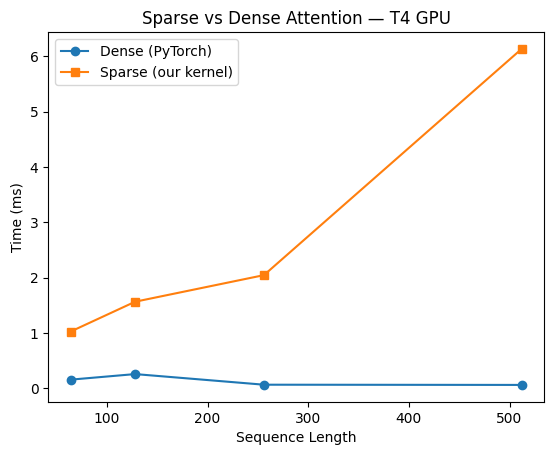

In [21]:
import matplotlib.pyplot as plt

seq_lens = [64, 128, 256, 512]
sparse_times = []
dense_times  = []

for N in seq_lens:
    Q = torch.randn(N, 64, device='cuda')
    K = torch.randn(N, 64, device='cuda')
    V = torch.randn(N, 64, device='cuda')

    mask = torch.zeros(N, N, dtype=torch.int32)
    for i in range(N):
        for j in range(N):
            mask[i,j] = 1 if (abs(i-j) <= 2 or j % 4 == 0) else 0
    mask = mask.cuda()

    sparse_times.append(benchmark(lambda: sa.sparse_attention(Q, K, V, mask)))
    dense_times.append(benchmark(lambda: pytorch_attention(Q, K, V)))

plt.plot(seq_lens, dense_times,  'o-', label='Dense (PyTorch)')
plt.plot(seq_lens, sparse_times, 's-', label='Sparse (our kernel)')
plt.xlabel('Sequence Length')
plt.ylabel('Time (ms)')
plt.title('Sparse vs Dense Attention — T4 GPU')
plt.legend()
plt.savefig('benchmark.png')
plt.show()